<a href="https://colab.research.google.com/github/EmanNajielsaied/neural-network-deep-learning/blob/main/day_2_0.1%20CNN_callbacks_Cifar-10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras import datasets

(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

In [2]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets, layers, models
import numpy as np

In [3]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [4]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

In [5]:
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

print('x_train shape: ', train_images.shape)
print('x_train test: ', test_images.shape)

x_train shape:  (60000, 28, 28, 1)
x_train test:  (10000, 28, 28, 1)


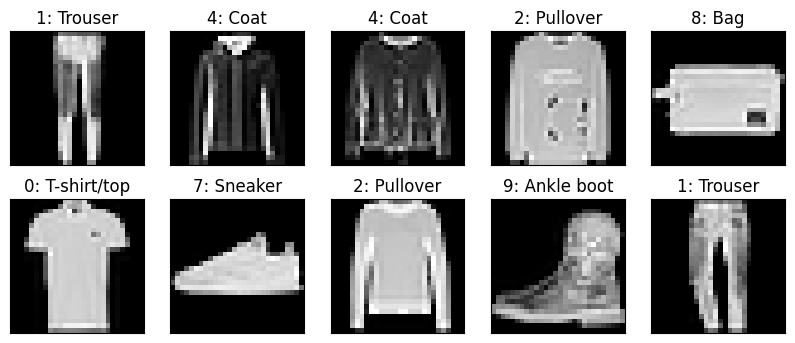

In [6]:
import matplotlib.pyplot as plt
import numpy as np

(_, _), (_, labels) = fashion_mnist.load_data()

idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]

clsmap = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

plt.figure(figsize=(10, 4))

for i, (img, y) in enumerate(zip(
    test_images[idx].reshape(10, 28, 28),
    labels[idx]
)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(str(y) + ": " + clsmap[y])

plt.show()

In [7]:
model1 = models.Sequential()

In [8]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

# dimensionality of input and latent encoded representations
inpt_dim = (28, 28, 1)
inpt_img = Input(shape=inpt_dim)

# Convolutional layer
c11 = Conv2D(
    64,
    (9, 9),
    strides=(2, 2),
    activation='relu'
)(inpt_img)

# Pooling and BatchNorm
p12 = MaxPooling2D(pool_size=(2, 2))(c11)
bn13 = BatchNormalization()(p12)

# Add a second convolutional layer
c14 = Conv2D(
    128,
    (3, 3),
    strides=(1, 1),
    activation='relu'
)(bn13)

p15 = MaxPooling2D(pool_size=(2, 2))(c14)
bn16 = BatchNormalization()(p15)

# Flattening for compatibility
f17 = Flatten()(bn16)

# Dense layers + Dropout
do18 = Dropout(0.5)(f17)

d19 = Dense(
    units=256,
    activation='relu'
)(do18)

do110 = Dropout(0.2)(d19)

d111 = Dense(
    units=64,
    activation='relu'
)(do110)

do112 = Dropout(0.1)(d111)

output = Dense(
    units=10,
    activation='softmax'
)(do112)

classifier = Model(inpt_img, output)

In [9]:
opt = RMSprop(learning_rate=0.001)

classifier.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(classifier.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 10, 10, 64)     │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,994 (507.79 KB)

 Trainable params: 129,610 (506.29 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [10]:
# Fitting the CNN to the images
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_delta=1e-4,
    mode='min',
    verbose=1
)

stop_alg = EarlyStopping(
    monitor='val_loss',
    patience=35,
    restore_best_weights=True,
    verbose=1
)

checkpoint_filepath = 'cnn_model.h5'

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

hist = classifier.fit(
    train_images,
    train_labels,
    batch_size=512,
    epochs=10,
    callbacks=[stop_alg, reduce_lr, model_checkpoint],
    shuffle=True,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5932 - loss: 0.2285

118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.7106 - loss: 0.1506 - val_accuracy: 0.1000 - val_loss: 0.3729 - learning_rate: 0.0010
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8162 - loss: 0.0926 - val_accuracy: 0.1000 - val_loss: 0.5369 - learning_rate: 0.0010
Epoch 3/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8354 - loss: 0.0834

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8394 - loss: 0.0810 - val_accuracy: 0.2335 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 4/10
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8478 - loss: 0.0764

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8516 - loss: 0.0744 - val_accuracy: 0.5665 - val_loss: 0.2310 - learning_rate: 0.0010
Epoch 5/10
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8558 - loss: 0.0718

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8569 - loss: 0.0707 - val_accuracy: 0.7419 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 6/10
111/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8638 - loss: 0.0679

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8639 - loss: 0.0677 - val_accuracy: 0.7875 - val_loss: 0.0935 - learning_rate: 0.0010
Epoch 7/10
111/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8694 - loss: 0.0646

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8695 - loss: 0.0647 - val_accuracy: 0.8307 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 8/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8739 - loss: 0.0620

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8738 - loss: 0.0624 - val_accuracy: 0.8559 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8775 - loss: 0.0609 - val_accuracy: 0.8547 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8805 - loss: 0.0591 - val_accuracy: 0.8494 - val_loss: 0.0727 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.


In [11]:
classifier.save_weights("cnn1.weights.h5")

In [12]:
classifier.load_weights("cnn1.weights.h5")

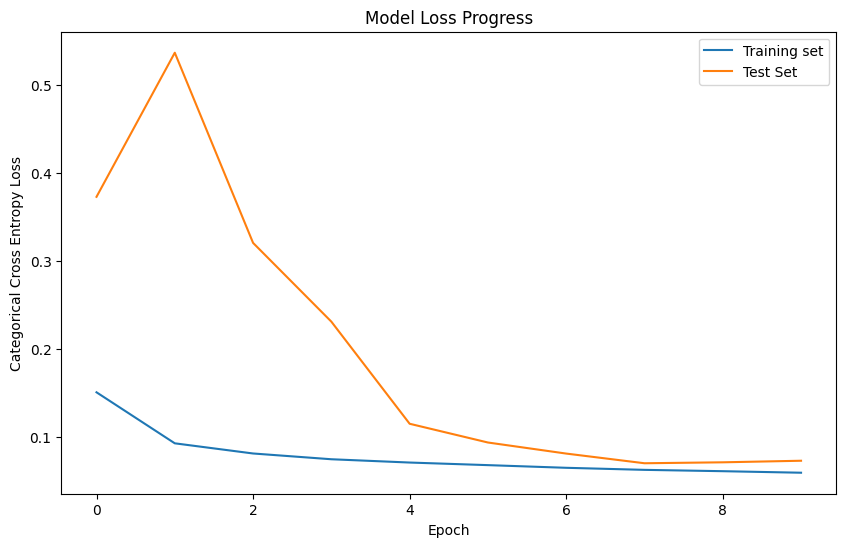

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,6))

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

plt.title('Model Loss Progress')
plt.ylabel('Categorical Cross Entropy Loss')
plt.xlabel('Epoch')

plt.legend(['Training set', 'Test Set'], loc='upper right')

plt.show()

In [14]:
classifier.load_weights('cnn1.weights.h5')

classifier.compile(optimizer=RMSprop(),loss='categorical_crossentropy',metrics=['accuracy'])

In [15]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import numpy as np

(_, _), (_, labels) = fashion_mnist.load_data()

y_ = labels

y_hat = classifier.predict(test_images)

y_pred = np.argmax(y_hat, axis=1)

print(classification_report(
    np.argmax(test_labels, axis=1),
    np.argmax(y_hat, axis=1),
    labels=[0,1,2,3,4,5,6,7,8,9]
))

cm = confusion_matrix(
    np.argmax(test_labels, axis=1),
    np.argmax(y_hat, axis=1),
    labels=[0,1,2,3,4,5,6,7,8,9]
)

print(cm)

ber = 1 - balanced_accuracy_score(
    np.argmax(test_labels, axis=1),
    np.argmax(y_hat, axis=1)
)

print('BER', ber)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.78      0.79      1000
           3       0.78      0.94      0.85      1000
           4       0.71      0.79      0.75      1000
           5       0.95      0.96      0.96      1000
           6       0.75      0.37      0.50      1000
           7       0.94      0.95      0.95      1000
           8       0.92      0.96      0.94      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000

[[879   2  18  61   3   2  30   0   5   0]
 [  2 966   0  28   1   0   1   0   2   0]
 [ 29   0 778  22 101   0  46   0  24   0]
 [ 20   3  10 941   8   0  16   0   2   0]
 [  5   0  71  85 793   0  2

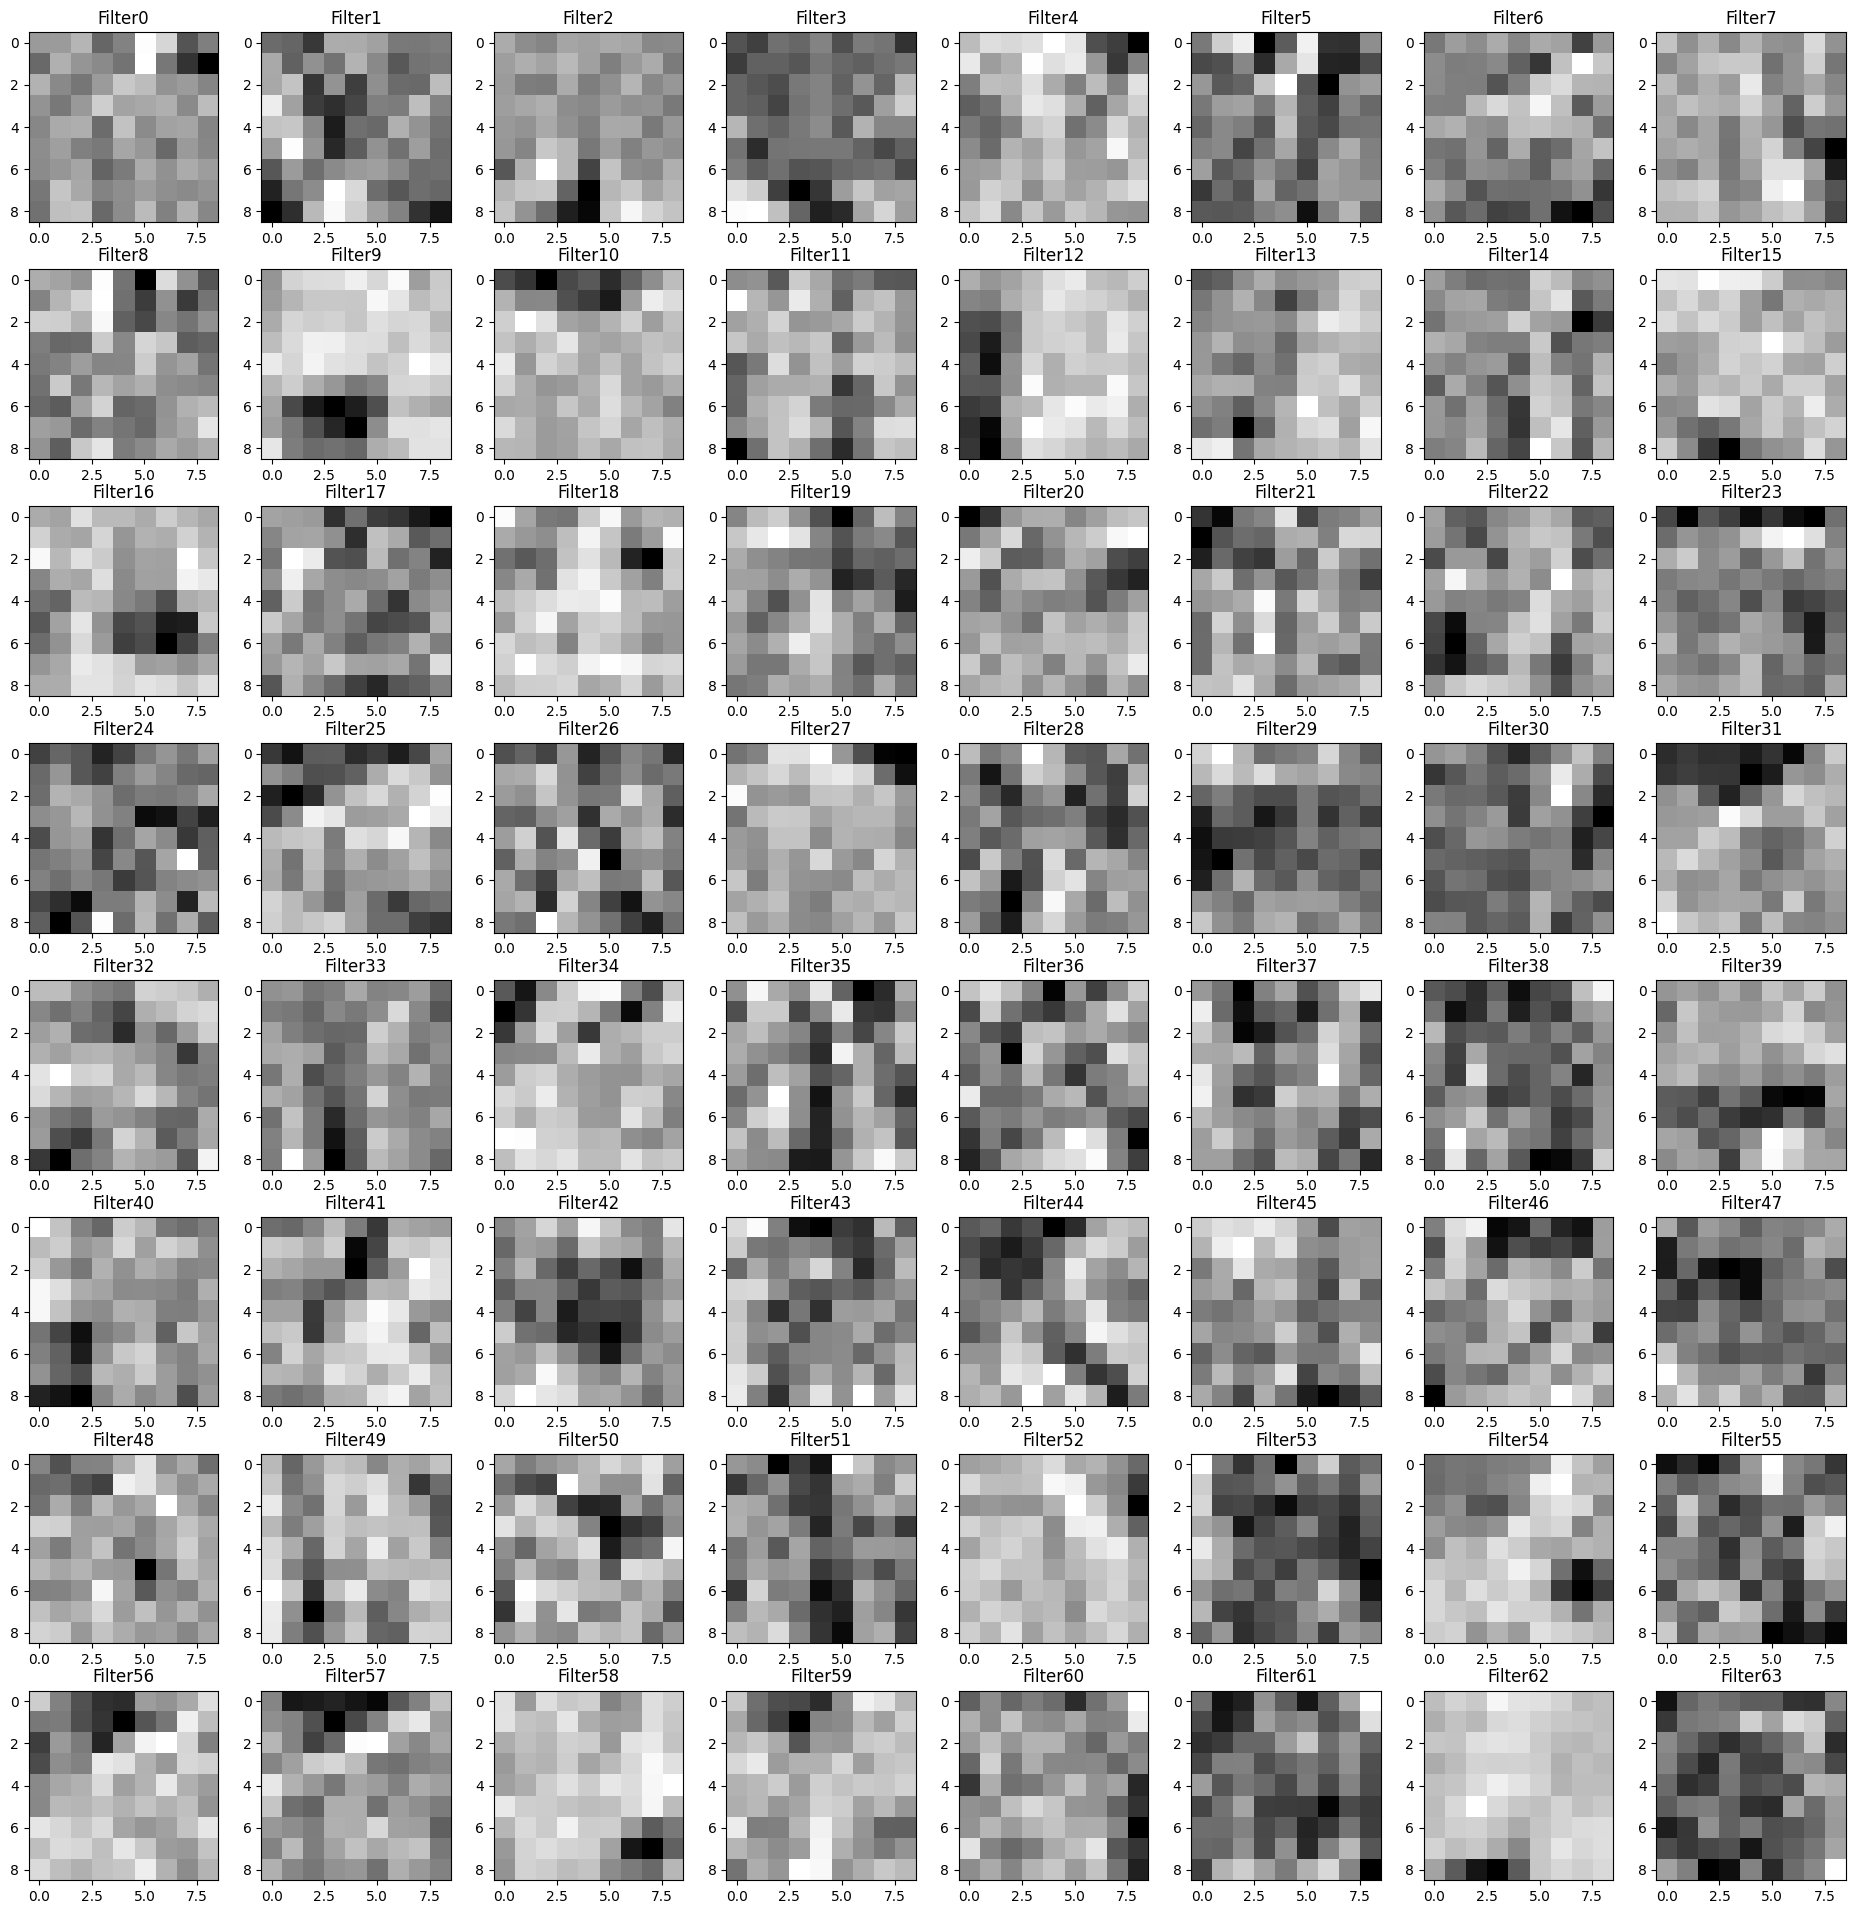

In [16]:
from sklearn.preprocessing import MinMaxScaler

cnn11 = classifier.layers[1].name

w = classifier.get_layer(name=cnn11).get_weights()[0]

wshape = w.shape

scaler = MinMaxScaler()

scaler.fit(w.reshape(-1,1))

w = scaler.transform(w.reshape(-1,1))

w = w.reshape(wshape)

fig, axs = plt.subplots(8, 8, figsize=(24,24))

fig.subplots_adjust(hspace=.25, wspace=.001)

axs = axs.ravel()

for i in range(w.shape[-1]):

    h = np.reshape(w[:,:,:,i], (9,9))

    axs[i].imshow(h, cmap='gray')

    axs[i].set_title('Filter' + str(i))

plt.show()